In [1]:
import os
import pickle
import re
import pandas as pd
import torch
from transformers import pipeline

os.chdir(r"C:\Users\Landl\Downloads\Data-Science-Projects\sec-financial-nlp")

with open("data/processed/all_texts.pkl", "rb") as f:
    all_texts_fixed = pickle.load(f)

df_ner = pd.read_csv("data/processed/ner_results.csv")

print(f"Filings: {len(all_texts_fixed)}")
print(f"NER entities: {len(df_ner)}")
print(f"GPU: {torch.cuda.is_available()}")

Filings: 125
NER entities: 7461
GPU: True


In [33]:
import os
from dotenv import load_dotenv

# Load and check
load_dotenv(override=True)
key = os.getenv("GROQ_API_KEY")

PII

In [2]:
def redact_pii(text):
    person_names = df_ner[df_ner["entity_type"] == "PER"]["entity_text"].unique()
    
    for name in person_names:
        text = re.sub(re.escape(name), "[PERSON]", text, flags=re.IGNORECASE)
    
    text = re.sub(r'[\w\.-]+@[\w\.-]+\.\w+', "[EMAIL]", text)
    text = re.sub(r'\(?\d{3}\)?[\s.-]\d{3}[\s.-]\d{4}', "[PHONE]", text)
    
    return text

In [3]:
sample_key = [k for k in all_texts_fixed if "AAPL_8-K" in k][0]
redacted = redact_pii(all_texts_fixed[sample_key])
print(redacted[:500])

ll-time high for all major product categories CUPERTINO, California — July 28, 2022 — Apple ® today announced financial results for its fiscal 2022 third quarter ended June 25, 2022. The Company posted a June quarter revenue record of $83.0 billion, up 2 percent year over year, and quarterly earnings per diluted share of $1.20. “This quarter’s record results speak to Apple’s constant efforts to innovate, to advance new possibilities, and to enrich the lives of our customers,” said [PERSON], Appl


In [4]:
redacted_texts = {}

for key, text in all_texts_fixed.items():
    redacted_texts[key] = redact_pii(text)

# Save
import pickle
with open("data/processed/redacted_texts.pkl", "wb") as f:
    pickle.dump(redacted_texts, f)

print(f"Saved {len(redacted_texts)} redacted filings.")


Saved 125 redacted filings.


In [7]:
# Check ALL companies properly
for ticker in ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]:
    keys = [k for k in redacted_texts if f"{ticker}_8-K" in k]
    total_person = sum(redacted_texts[k].count("[PERSON]") for k in keys)
    total_email = sum(redacted_texts[k].count("[EMAIL]") for k in keys)
    print(f"{ticker}: {len(keys)} filings, {total_person} [PERSON] total, {total_email} [EMAIL] total")

AAPL: 20 filings, 33 [PERSON] total, 34 [EMAIL] total
MSFT: 20 filings, 16 [PERSON] total, 12 [EMAIL] total
GOOGL: 20 filings, 20 [PERSON] total, 22 [EMAIL] total
JPM: 20 filings, 20 [PERSON] total, 0 [EMAIL] total
TSLA: 20 filings, 6 [PERSON] total, 9 [EMAIL] total


Financial Summarization.

In [4]:
from groq import Groq
from dotenv import load_dotenv
import os

load_dotenv()
client = Groq(api_key=os.getenv("GROQ_API_KEY"))
print("Groq client ready.")

Groq client ready.


In [5]:
def summarize_filing(text, ticker, filing_type):
    # Take words 2000-5000 — real content zone, verified earlier
    content = " ".join(text.split()[2000:5000])
    
    prompt = f"""You are a financial analyst. Summarize the following excerpt from {ticker}'s {filing_type} filing in 3-4 sentences.
      Focus on business overview, key risks, and financial performance. Be concise and factual.

Filing excerpt:
{content}

Summary:"""
    
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200,
        temperature=0.3
    )
    
    return response.choices[0].message.content.strip()

In [8]:
sample_key = [k for k in all_texts_fixed if "AAPL_10-K" in k][0]
summary = summarize_filing(all_texts_fixed[sample_key], "AAPL", "10-K")
print(summary)

Apple Inc.'s business overview is impacted by various factors, including the COVID-19 pandemic, which has disrupted its manufacturing, supply chain, and sales. The company faces significant risks, such as intense competition in the global markets for its products and services, rapid technological changes, and dependence on outsourcing partners for manufacturing and logistical services. Apple's financial performance is also exposed to risks, including supply chain disruptions, component shortages, and potential write-downs on inventory and other assets. The company's ability to innovate and introduce new products and services is crucial to maintaining its competitive advantage and driving future growth.


In [9]:
tenk_keys = [k for k in all_texts_fixed if "10-K" in k]
summaries = {}

for key in tenk_keys:
    ticker = key.split("_")[0]
    print(f"Summarizing {key}...")
    summaries[key] = summarize_filing(all_texts_fixed[key], ticker, "10-K")

import pandas as pd
df_summaries = pd.DataFrame([
    {"filing": k, "ticker": k.split("_")[0], "summary": v}
    for k, v in summaries.items()
])
df_summaries.to_csv("data/processed/summarization_results.csv", index=False)
print(f"Saved {len(df_summaries)} summaries.")

Summarizing AAPL_10-K_0000320193-20-000096...
Summarizing AAPL_10-K_0000320193-21-000105...
Summarizing AAPL_10-K_0000320193-22-000108...
Summarizing AAPL_10-K_0000320193-23-000106...
Summarizing AAPL_10-K_0000320193-24-000123...
Summarizing MSFT_10-K_0000950170-23-035122...
Summarizing MSFT_10-K_0000950170-24-087843...
Summarizing MSFT_10-K_0001564590-20-034944...
Summarizing MSFT_10-K_0001564590-21-039151...
Summarizing MSFT_10-K_0001564590-22-026876...
Summarizing GOOGL_10-K_0001652044-20-000008...
Summarizing GOOGL_10-K_0001652044-21-000010...
Summarizing GOOGL_10-K_0001652044-22-000019...
Summarizing GOOGL_10-K_0001652044-23-000016...
Summarizing GOOGL_10-K_0001652044-24-000022...
Summarizing JPM_10-K_0000019617-20-000257...
Summarizing JPM_10-K_0000019617-21-000236...
Summarizing JPM_10-K_0000019617-22-000272...
Summarizing JPM_10-K_0000019617-23-000231...
Summarizing JPM_10-K_0000019617-24-000225...
Summarizing TSLA_10-K_0000950170-22-000796...
Summarizing TSLA_10-K_0000950170-2

In [10]:
for _, row in df_summaries.iterrows():
    print(f"\n=== {row['filing']} ===")
    print(row['summary'])


=== AAPL_10-K_0000320193-20-000096 ===
Here is a 3-4 sentence summary of the excerpt from AAPL's 10-K filing, focusing on business overview, key risks, and financial performance:

Apple Inc.'s business, financial condition, and operating results are subject to various risks, including the COVID-19 pandemic, global and regional economic conditions, and intense competition in the technology industry. The company's financial performance depends on its ability to innovate and introduce new products and services, manage its supply chain and manufacturing operations, and navigate risks associated with outsourcing and component sourcing. The COVID-19 pandemic has already had a material adverse impact on the company's business, and ongoing global economic uncertainty and competitive pressures may continue to affect its financial condition and operating results. Apple's ability to mitigate these risks and maintain its competitive advantage will be critical to its future financial performance.


In [11]:
import re

def clean_summary(text):
    # Strip common preamble patterns before the actual summary
    text = re.sub(
        r'^(Here is a.*?summary.*?:|As a financial analyst.*?:)\s*',
        '', text, flags=re.IGNORECASE | re.DOTALL
    )
    return text.strip()

df_summaries['summary'] = df_summaries['summary'].apply(clean_summary)
df_summaries.to_csv("data/processed/summarization_results.csv", index=False)
print("Cleaned and re-saved.")

Cleaned and re-saved.


In [12]:
for filing in ["GOOGL_10-K_0001652044-21-000010", "JPM_10-K_0000019617-21-000236", "JPM_10-K_0000019617-24-000225"]:
    print(f"\n=== {filing} ===")
    print(df_summaries[df_summaries["filing"] == filing]["summary"].values[0])


=== GOOGL_10-K_0001652044-21-000010 ===
Alphabet Inc., the parent company of Google, generates most of its revenue from advertising, with over 80% of total revenues coming from online ad display in 2020. The company's business is subject to various risks, including reduced spending by advertisers, loss of partners, and new technologies that block ads online. Google's financial performance is also affected by seasonal fluctuations in internet usage and advertising expenditures, as well as competition from other tech companies. The company is investing in new areas, such as Google Cloud, hardware, and YouTube, to drive long-term growth and reduce dependence on advertising revenue.

=== JPM_10-K_0000019617-21-000236 ===
JPMorgan Chase operates under various regulatory requirements, including capital and liquidity standards set by the Federal Reserve and the OCC, which are generally consistent with the Basel III framework. The firm is subject to stress testing, enhanced prudential standar

KEYWORD Extracttion

In [2]:
from keybert import KeyBERT

kw_model = KeyBERT()
print("KeyBERT ready.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

KeyBERT ready.


In [63]:
import re

def get_content_window(text, window_size=3000, min_gap=3000):
    """
    Finds the real 'Item 1A. Risk Factors' section start by locating all
    'Item 1A' / 'Item 1B' mentions and picking the Item 1A whose distance
    to the NEXT Item 1B exceeds a minimum gap (real sections are long;
    TOC entries and cross-references are short or don't have a large gap).
    """
    text_lower = text.lower()
    words = text.split()

    item_1a_positions = [m.start() for m in re.finditer(r'item\s+1a', text_lower)]
    item_1b_positions = [m.start() for m in re.finditer(r'item\s+1b', text_lower)]

    best_pos = 0
    for pos_a in item_1a_positions:
        later_1b = [p for p in item_1b_positions if p > pos_a]
        if not later_1b:
            continue
        gap = min(later_1b) - pos_a
        if gap >= min_gap:
            best_pos = pos_a
            break  # take the FIRST candidate meeting the threshold, not the biggest gap

    start_word_idx = len(text[:best_pos].split())
    return " ".join(words[start_word_idx : start_word_idx + window_size])


In [71]:
def extract_keywords(text, top_n=15, min_score=0.25):
    content = get_content_window(text)
    keywords = kw_model.extract_keywords(
        content,
        keyphrase_ngram_range=(1, 1),  # changed from (1, 2) — single words only, avoids broken bigrams
        stop_words="english",
        top_n=top_n,
        use_mmr=True,
        diversity=0.5
    )
    return [(kw, score) for kw, score in keywords if score >= min_score]

In [72]:
tenk_keys = [k for k in all_texts_fixed if "10-K" in k]
keyword_results = {}

for key in tenk_keys:
    keyword_results[key] = extract_keywords(all_texts_fixed[key])

rows = []
for key, kws in keyword_results.items():
    ticker = key.split("_")[0]
    for kw, score in kws:
        rows.append({"filing": key, "ticker": ticker, "keyword": kw, "score": score})

df_keywords = pd.DataFrame(rows)
df_keywords.to_csv("data/processed/keyword_results.csv", index=False)
print(f"Total filings processed: {len(keyword_results)}")
print(f"Total keywords extracted: {len(df_keywords)}")

Total filings processed: 25
Total keywords extracted: 214


In [74]:
print(df_keywords.to_string())

                              filing ticker            keyword   score
0     AAPL_10-K_0000320193-20-000096   AAPL              risks  0.3559
1     AAPL_10-K_0000320193-20-000096   AAPL      profitability  0.3255
2     AAPL_10-K_0000320193-20-000096   AAPL         statements  0.3170
3     AAPL_10-K_0000320193-20-000096   AAPL        performance  0.2959
4     AAPL_10-K_0000320193-20-000096   AAPL          recession  0.2656
5     AAPL_10-K_0000320193-20-000096   AAPL            factors  0.2610
6     AAPL_10-K_0000320193-20-000096   AAPL             future  0.2605
7     AAPL_10-K_0000320193-21-000105   AAPL              risks  0.4744
8     AAPL_10-K_0000320193-21-000105   AAPL              stock  0.3624
9     AAPL_10-K_0000320193-21-000105   AAPL      profitability  0.3602
10    AAPL_10-K_0000320193-21-000105   AAPL          liquidity  0.3070
11    AAPL_10-K_0000320193-21-000105   AAPL             future  0.3045
12    AAPL_10-K_0000320193-21-000105   AAPL          condition  0.2940
13    

In [73]:
import inspect
print(inspect.getsource(extract_keywords))

def extract_keywords(text, top_n=15, min_score=0.25):
    content = get_content_window(text)
    keywords = kw_model.extract_keywords(
        content,
        keyphrase_ngram_range=(1, 1),  # changed from (1, 2) — single words only, avoids broken bigrams
        stop_words="english",
        top_n=top_n,
        use_mmr=True,
        diversity=0.5
    )
    return [(kw, score) for kw, score in keywords if score >= min_score]



clustering filings by risk profile

In [75]:
# Elbow Method

from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")  # small, fast, well-established for this kind of task

tenk_keys = [k for k in all_texts_fixed if "10-K" in k]

filing_texts = {}
for key in tenk_keys:
    filing_texts[key] = get_content_window(all_texts_fixed[key])

embeddings = embed_model.encode(list(filing_texts.values()), show_progress_bar=True)
print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (25, 384)


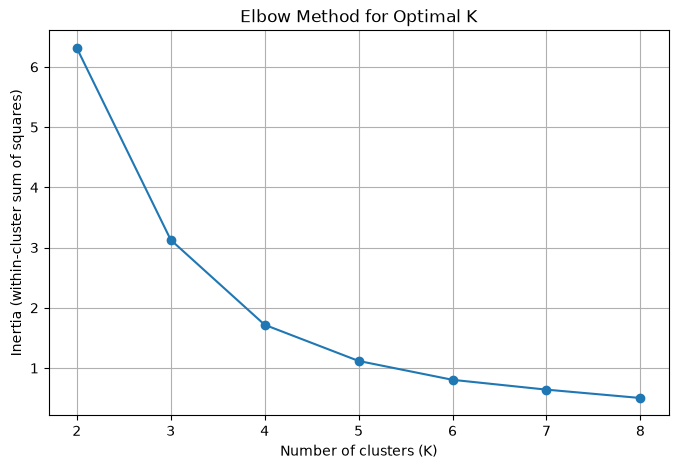

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(embeddings)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.savefig("data/processed/elbow_plot.png")
plt.show()

In [77]:
final_k = 5
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embeddings)

df_clusters = pd.DataFrame({
    "filing": list(filing_texts.keys()),
    "ticker": [k.split("_")[0] for k in filing_texts.keys()],
    "cluster": cluster_labels
})

df_clusters = df_clusters.sort_values(["cluster", "ticker"]).reset_index(drop=True)
df_clusters.to_csv("data/processed/cluster_results.csv", index=False)
print(df_clusters.to_string())

                             filing ticker  cluster
0    MSFT_10-K_0000950170-23-035122   MSFT        0
1    MSFT_10-K_0000950170-24-087843   MSFT        0
2    MSFT_10-K_0001564590-20-034944   MSFT        0
3    MSFT_10-K_0001564590-21-039151   MSFT        0
4    MSFT_10-K_0001564590-22-026876   MSFT        0
5     JPM_10-K_0000019617-20-000257    JPM        1
6     JPM_10-K_0000019617-21-000236    JPM        1
7     JPM_10-K_0000019617-22-000272    JPM        1
8     JPM_10-K_0000019617-23-000231    JPM        1
9     JPM_10-K_0000019617-24-000225    JPM        1
10   TSLA_10-K_0000950170-22-000796   TSLA        2
11   TSLA_10-K_0000950170-23-001409   TSLA        2
12   TSLA_10-K_0001564590-20-004475   TSLA        2
13   TSLA_10-K_0001564590-21-004599   TSLA        2
14   TSLA_10-K_0001628280-24-002390   TSLA        2
15   AAPL_10-K_0000320193-20-000096   AAPL        3
16   AAPL_10-K_0000320193-21-000105   AAPL        3
17   AAPL_10-K_0000320193-22-000108   AAPL        3
18   AAPL_10

In [78]:
print(pd.crosstab(df_clusters["ticker"], df_clusters["cluster"]))

cluster  0  1  2  3  4
ticker                
AAPL     0  0  0  5  0
GOOGL    0  0  0  0  5
JPM      0  5  0  0  0
MSFT     5  0  0  0  0
TSLA     0  0  5  0  0


In [80]:
for c in range(final_k):
    filings_in_cluster = df_clusters[df_clusters["cluster"] == c]["filing"].tolist()
    cluster_keywords = df_keywords[df_keywords["filing"].isin(filings_in_cluster)]
    top_terms = cluster_keywords.groupby("keyword")["score"].mean().sort_values(ascending=False).head(10)
    print(f"\n=== Cluster {c} ({len(filings_in_cluster)} filings: {[k.split('_')[0] for k in filings_in_cluster]}) ===")
    print(top_terms)


=== Cluster 0 (5 filings: ['MSFT', 'MSFT', 'MSFT', 'MSFT', 'MSFT']) ===
keyword
disclosures      0.4270
uncertainties    0.4021
risks            0.3720
future           0.3592
statements       0.3464
strategic        0.3223
investment       0.3188
expect           0.3157
indirect         0.2829
enterprise       0.2647
Name: score, dtype: float64

=== Cluster 1 (5 filings: ['JPM', 'JPM', 'JPM', 'JPM', 'JPM']) ===
keyword
jpmorgan       0.481760
banking        0.372900
risks          0.347620
regulation     0.328800
bankruptcy     0.313700
securities     0.303300
regulatory     0.290200
chase          0.289860
prosecution    0.262900
liquidity      0.261725
Name: score, dtype: float64

=== Cluster 2 (5 filings: ['TSLA', 'TSLA', 'TSLA', 'TSLA', 'TSLA']) ===
keyword
tesla                0.433300
superchargers        0.428300
risks                0.422000
automotive           0.413175
consumer             0.386000
business             0.386000
manufacturability    0.380620
powertrain      